# Vergleich aller oemof Energiesystem-Ergebnisse

Dieses Notebook lädt automatisch alle `*_complete.csv` Dateien aus dem Verzeichnis und vergleicht sie.

**Funktionen:**
- Automatisches Erkennen aller Complete-CSV-Dateien
- Laden und Vergleichen aller Cases
- Energiesummen-Berechnung und Vergleich
- Visualisierung der Unterschiede
- Berechnung von Kennzahlen (Betriebsstunden, etc.)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Konfiguration für bessere Darstellung
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Bibliotheken erfolgreich geladen")

✓ Bibliotheken erfolgreich geladen


## 2. Alle Complete-CSV-Dateien finden und laden

In [2]:
# Finde alle *_complete.csv Dateien im aktuellen Verzeichnis
current_dir = Path()
csv_files = sorted(current_dir.glob("*_complete.csv"))

print("="*80)
print("GEFUNDENE COMPLETE-CSV-DATEIEN:")
print("="*80)

if csv_files:
    for i, file in enumerate(csv_files, 1):
        print(f"{i:2d}. {file.name}")
    print(f"\n✓ {len(csv_files)} Dateien gefunden")
else:
    print("⚠ Keine *_complete.csv Dateien gefunden")

print("="*80)

GEFUNDENE COMPLETE-CSV-DATEIEN:
 1. case11_pv_BEV_with_full_load_time_max_100h_complete.csv
 2. case11_pv_BEV_with_full_load_time_max_10h_complete.csv
 3. case11_pv_BEV_with_full_load_time_max_False_complete.csv

✓ 3 Dateien gefunden


In [3]:
# Lade alle gefundenen CSV-Dateien
print("\n" + "="*80)
print("LADE CSV-DATEIEN...")
print("="*80)

case_data = {}  # Dictionary zum Speichern aller DataFrames

for csv_file in csv_files:
    try:
        # Extrahiere Case-Name aus Dateiname (ohne _complete.csv)
        case_name = csv_file.stem.replace("_complete", "")
        
        # Lade CSV mit Zeitindex
        df = pd.read_csv(csv_file, index_col=0, parse_dates=True)
        
        # Speichere im Dictionary
        case_data[case_name] = df
        
        print(f"✓ {case_name}: {len(df)} Zeitschritte, {len(df.columns)} Spalten")
        
    except Exception as e:
        print(f"✗ Fehler bei {csv_file.name}: {e}")

print(f"\n{'='*80}")
print(f"✓ {len(case_data)} Cases erfolgreich geladen")
print("="*80)


LADE CSV-DATEIEN...
✓ case11_pv_BEV_with_full_load_time_max_100h: 35041 Zeitschritte, 7 Spalten
✓ case11_pv_BEV_with_full_load_time_max_10h: 35041 Zeitschritte, 7 Spalten
✓ case11_pv_BEV_with_full_load_time_max_False: 35041 Zeitschritte, 7 Spalten

✓ 3 Cases erfolgreich geladen


## 3. Übersicht über alle geladenen Cases

In [4]:
# Übersicht über alle Cases
print("="*80)
print("ÜBERSICHT ALLER CASES:")
print("="*80)

for case_name, df in case_data.items():
    print(f"\n{case_name}:")
    print(f"  - Zeitraum: {df.index[0]} bis {df.index[-1]}")
    print(f"  - Zeitschritte: {len(df)}")
    print(f"  - Spalten: {len(df.columns)}")
    print(f"  - Spalten: {', '.join(df.columns.tolist())}")

print("="*80)

ÜBERSICHT ALLER CASES:

case11_pv_BEV_with_full_load_time_max_100h:
  - Zeitraum: 2022-01-01 00:00:00 bis 2023-01-01 00:00:00
  - Zeitschritte: 35041
  - Spalten: 7
  - Spalten: Haushaltslast [kW], PV-Erzeugung [kW], Netzbezug [kW], Netzeinspeisung [kW], BEV Laden [kW], BEV Entladen [kW], BEV Ladezustand [kWh]

case11_pv_BEV_with_full_load_time_max_10h:
  - Zeitraum: 2022-01-01 00:00:00 bis 2023-01-01 00:00:00
  - Zeitschritte: 35041
  - Spalten: 7
  - Spalten: Haushaltslast [kW], PV-Erzeugung [kW], Netzbezug [kW], Netzeinspeisung [kW], BEV Laden [kW], BEV Entladen [kW], BEV Ladezustand [kWh]

case11_pv_BEV_with_full_load_time_max_False:
  - Zeitraum: 2022-01-01 00:00:00 bis 2023-01-01 00:00:00
  - Zeitschritte: 35041
  - Spalten: 7
  - Spalten: Haushaltslast [kW], PV-Erzeugung [kW], Netzbezug [kW], Netzeinspeisung [kW], BEV Laden [kW], BEV Entladen [kW], BEV Ladezustand [kWh]


## 4. Berechne Energiesummen für alle Cases

In [5]:
def calculate_energy_sums(df: pd.DataFrame, case_name: str) -> pd.Series:
    """
    Berechnet Energiesummen für einen Case
    """
    # Zeitschrittlänge berechnen (in Stunden)
    if len(df) > 1:
        time_step_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
    else:
        time_step_hours = 0.25  # Default: 15 Minuten
    
    sums = {}
    
    # Berechne Summen für alle Leistungsspalten (ohne Ladezustand)
    for col in df.columns:
        if '[kW]' in col and 'Ladezustand' not in col:
            energy_kwh = (df[col] * time_step_hours).sum()
            sums[col.replace('[kW]', '[kWh]')] = energy_kwh
            
            # Berechne auch Betriebsstunden (wenn > 0)
            betriebsstunden = (df[col] > 0).sum() * time_step_hours
            sums[col.replace('[kW]', '[Betriebsstunden]')] = betriebsstunden
    
    # Maximale und minimale Ladezustände
    for col in df.columns:
        if 'Ladezustand' in col:
            sums[f"{col.replace('[kWh]', '')}Max [kWh]"] = df[col].max()
            sums[f"{col.replace('[kWh]', '')}Min [kWh]"] = df[col].min()
    
    return pd.Series(sums, name=case_name)


# Berechne Energiesummen für alle Cases
print("="*80)
print("BERECHNE ENERGIESUMMEN...")
print("="*80)

energy_comparison = pd.DataFrame()

for case_name, df in case_data.items():
    sums = calculate_energy_sums(df, case_name)
    energy_comparison[case_name] = sums

print(f"✓ Energiesummen für {len(energy_comparison.columns)} Cases berechnet")
print("="*80)

BERECHNE ENERGIESUMMEN...
✓ Energiesummen für 3 Cases berechnet


## 5. Vergleichstabelle anzeigen

In [6]:
# Zeige vollständige Vergleichstabelle
print("\n" + "="*80)
print("ENERGIESUMMEN-VERGLEICH ALLER CASES")
print("="*80)
print("\n")
display(energy_comparison)


ENERGIESUMMEN-VERGLEICH ALLER CASES




,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
Haushaltslast [kWh],5010.096483,5010.096483,5010.096483
Haushaltslast [Betriebsstunden],8760.000000,8760.000000,8760.000000
PV-Erzeugung [kWh],11883.512306,11883.512306,11883.512306
PV-Erzeugung [Betriebsstunden],4455.000000,4455.000000,4455.000000
Netzbezug [kWh],708.078252,2621.579084,708.078252
Netzbezug [Betriebsstunden],1135.750000,4758.000000,1135.500000
Netzeinspeisung [kWh],6562.113016,8800.125683,6562.113016
Netzeinspeisung [Betriebsstunden],2195.750000,3101.250000,2195.750000
BEV Laden [kWh],2995.237795,869.125761,2995.237795
BEV Laden [Betriebsstunden],1498.750000,619.250000,1498.750000


In [7]:
# Zeige nur Energiesummen (ohne Betriebsstunden und Min/Max)
energy_sums_only = energy_comparison.loc[
    [idx for idx in energy_comparison.index if '[kWh]' in idx and 'Betriebsstunden' not in idx and 'Max' not in idx and 'Min' not in idx]
]

print("\n" + "="*80)
print("NUR ENERGIESUMMEN [kWh]")
print("="*80)
display(energy_sums_only)


NUR ENERGIESUMMEN [kWh]


,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
Haushaltslast [kWh],5010.096483,5010.096483,5010.096483
PV-Erzeugung [kWh],11883.512306,11883.512306,11883.512306
Netzbezug [kWh],708.078252,2621.579084,708.078252
Netzeinspeisung [kWh],6562.113016,8800.125683,6562.113016
BEV Laden [kWh],2995.237795,869.125761,2995.237795
BEV Entladen [kWh],3052.987796,926.875762,3052.987796


In [8]:
# Zeige nur Betriebsstunden
betriebsstunden_only = energy_comparison.loc[
    [idx for idx in energy_comparison.index if 'Betriebsstunden' in idx]
]

print("\n" + "="*80)
print("BETRIEBSSTUNDEN")
print("="*80)
display(betriebsstunden_only)


BETRIEBSSTUNDEN


,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
Haushaltslast [Betriebsstunden],8760.00,8760.00,8760.00
PV-Erzeugung [Betriebsstunden],4455.00,4455.00,4455.00
Netzbezug [Betriebsstunden],1135.75,4758.00,1135.50
Netzeinspeisung [Betriebsstunden],2195.75,3101.25,2195.75
BEV Laden [Betriebsstunden],1498.75,619.25,1498.75
BEV Entladen [Betriebsstunden],4339.50,740.75,4339.75


In [9]:
# Berechne Volllaststunden für alle Cases
# Volllaststunden = Jahresenergie [kWh] / Peak-Leistung [kW]

volllaststunden_data = {}

for case_name, df in case_data.items():
    # Zeitschrittlänge berechnen
    if len(df) > 1:
        time_step_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
    else:
        time_step_hours = 0.25
    
    volllaststunden = {}
    
    # Berechne für alle Leistungsspalten
    for col in df.columns:
        if '[kW]' in col and 'Ladezustand' not in col:
            # Jahresenergie
            jahresenergie = (df[col] * time_step_hours).sum()
            
            # Peak-Leistung (Maximum)
            peak_leistung = df[col].max()
            
            # Volllaststunden berechnen
            if peak_leistung > 0:
                vlh = jahresenergie / peak_leistung
                component_name = col.replace(' [kW]', '')
                volllaststunden[f"{component_name} [Volllaststunden]"] = vlh
    
    volllaststunden_data[case_name] = pd.Series(volllaststunden)

# Erstelle DataFrame mit Volllaststunden
volllaststunden_df = pd.DataFrame(volllaststunden_data)

print("\n" + "="*80)
print("VOLLLASTSTUNDEN")
print("="*80)
print("\nVolllaststunden = Jahresenergie / Peak-Leistung")
print("Zeigt die Auslastung der Anlagen über das Jahr\n")
display(volllaststunden_df)


VOLLLASTSTUNDEN

Volllaststunden = Jahresenergie / Peak-Leistung
Zeigt die Auslastung der Anlagen über das Jahr



,case11_pv_BEV_with_full_load_time_max_100h,case11_pv_BEV_with_full_load_time_max_10h,case11_pv_BEV_with_full_load_time_max_False
Haushaltslast [Volllaststunden],235.268079,235.268079,235.268079
PV-Erzeugung [Volllaststunden],2091.744554,2091.744554,2091.744554
Netzbezug [Volllaststunden],44.018208,145.147764,44.018208
Netzeinspeisung [Volllaststunden],1184.272393,1588.169218,1184.272393
BEV Laden [Volllaststunden],581.491730,169.326931,581.491730
BEV Entladen [Volllaststunden],152.130033,46.343788,152.130033


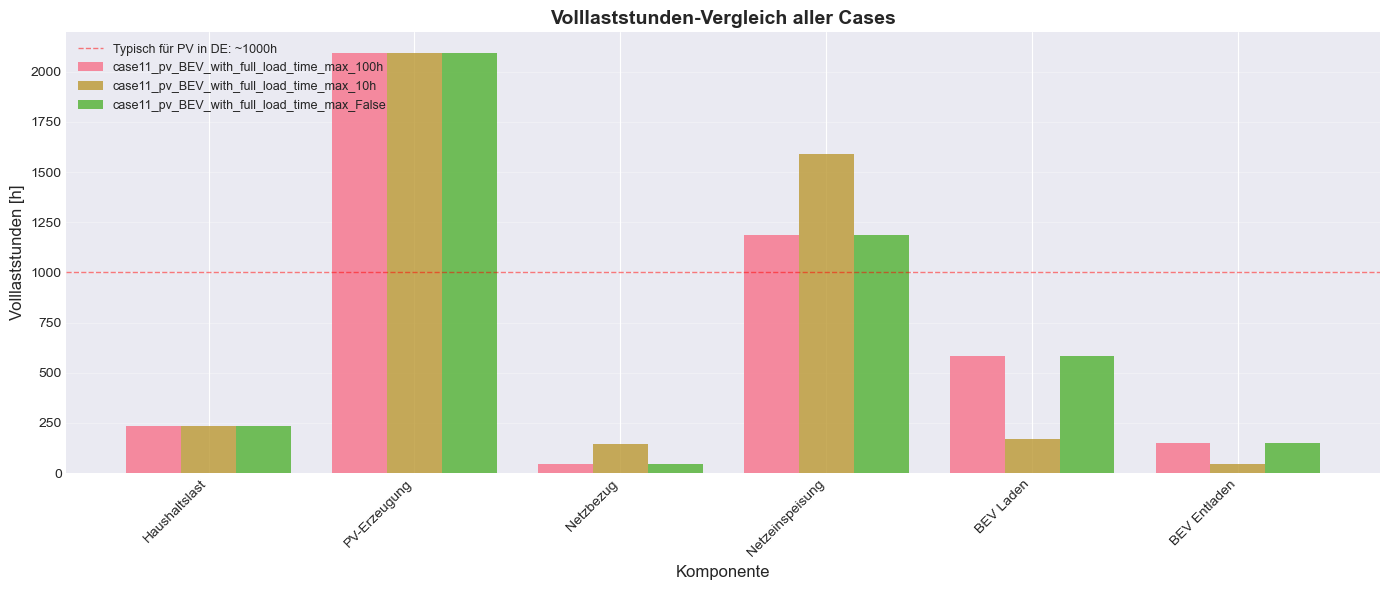

In [10]:
# Visualisierung: Volllaststunden-Vergleich
volllaststunden_cols = volllaststunden_df.index.tolist()

if volllaststunden_cols and len(volllaststunden_df.columns) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(volllaststunden_cols))
    width = 0.8 / len(volllaststunden_df.columns)
    
    for i, case in enumerate(volllaststunden_df.columns):
        values = volllaststunden_df.loc[volllaststunden_cols, case]
        offset = (i - len(volllaststunden_df.columns)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=case, alpha=0.8)
    
    ax.set_xlabel('Komponente', fontsize=12)
    ax.set_ylabel('Volllaststunden [h]', fontsize=12)
    ax.set_title('Volllaststunden-Vergleich aller Cases', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace(' [Volllaststunden]', '') for col in volllaststunden_cols], rotation=45, ha='right')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Füge Referenzlinie für typische PV-Volllaststunden in Deutschland hinzu
    ax.axhline(y=1000, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Typisch für PV in DE: ~1000h')
    ax.legend(fontsize=9, loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Keine Volllaststunden-Daten zum Plotten")

## 6. Visualisierung der Vergleiche

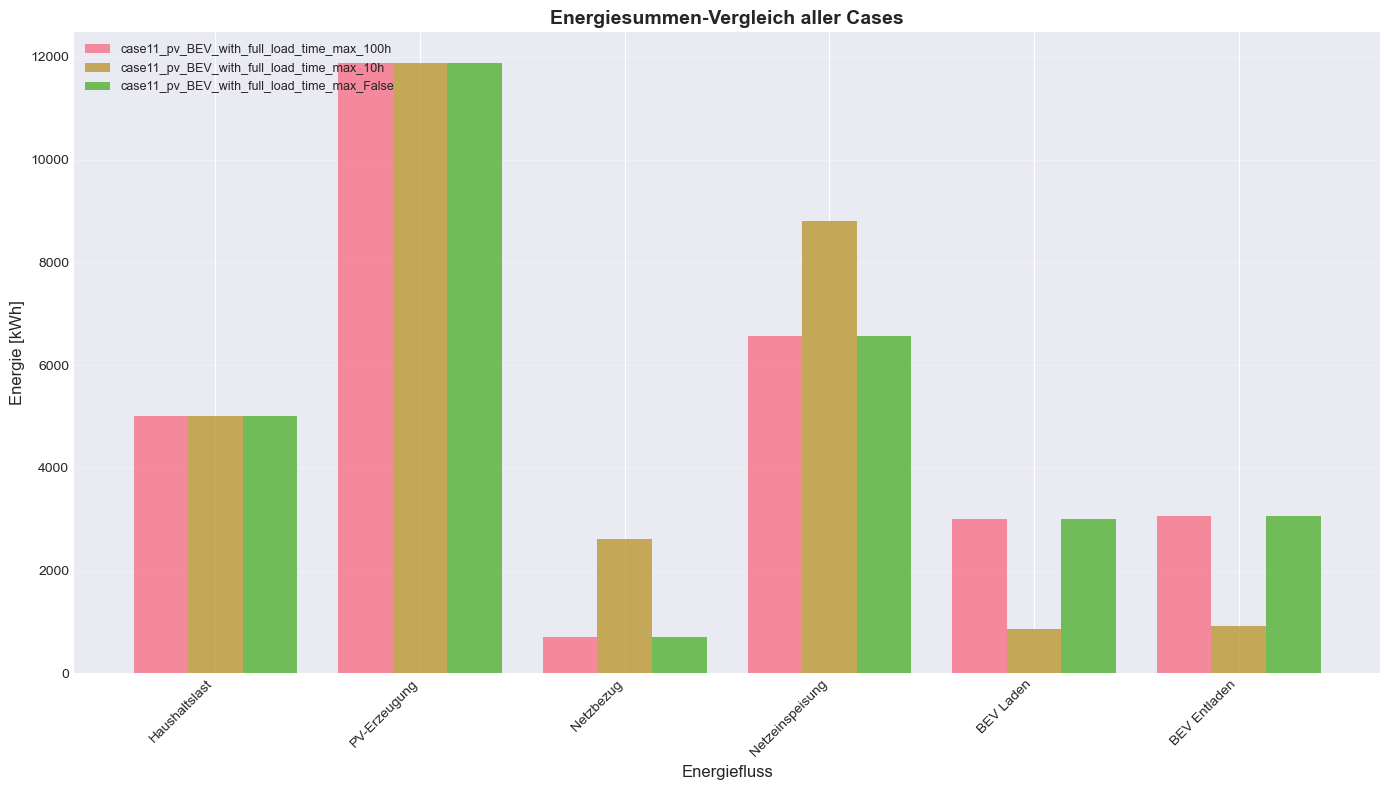

In [11]:
# Balkendiagramm für Energiesummen-Vergleich
energy_cols = [col for col in energy_sums_only.index]
comparison_cases = energy_sums_only.columns.tolist()

if energy_cols and len(comparison_cases) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(energy_cols))
    width = 0.8 / len(comparison_cases)
    
    for i, case in enumerate(comparison_cases):
        values = energy_sums_only.loc[energy_cols, case]
        offset = (i - len(comparison_cases)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=case, alpha=0.8)
    
    ax.set_xlabel('Energiefluss', fontsize=12)
    ax.set_ylabel('Energie [kWh]', fontsize=12)
    ax.set_title('Energiesummen-Vergleich aller Cases', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace(' [kWh]', '') for col in energy_cols], rotation=45, ha='right')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Keine Daten zum Plotten")

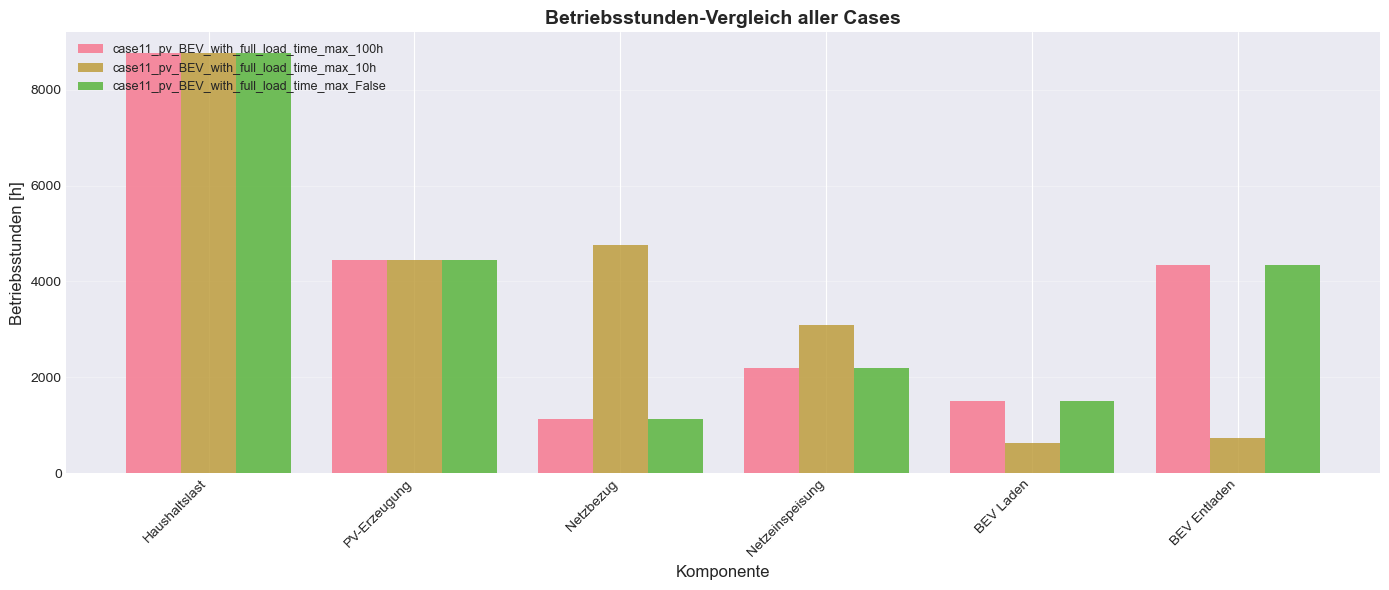

In [12]:
# Balkendiagramm für Betriebsstunden-Vergleich
betriebsstunden_cols = betriebsstunden_only.index.tolist()

if betriebsstunden_cols and len(comparison_cases) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(betriebsstunden_cols))
    width = 0.8 / len(comparison_cases)
    
    for i, case in enumerate(comparison_cases):
        values = betriebsstunden_only.loc[betriebsstunden_cols, case]
        offset = (i - len(comparison_cases)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=case, alpha=0.8)
    
    ax.set_xlabel('Komponente', fontsize=12)
    ax.set_ylabel('Betriebsstunden [h]', fontsize=12)
    ax.set_title('Betriebsstunden-Vergleich aller Cases', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace(' [Betriebsstunden]', '') for col in betriebsstunden_cols], rotation=45, ha='right')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Keine Betriebsstunden-Daten zum Plotten")

## 7. Zeitreihen-Vergleich für spezifische Spalten

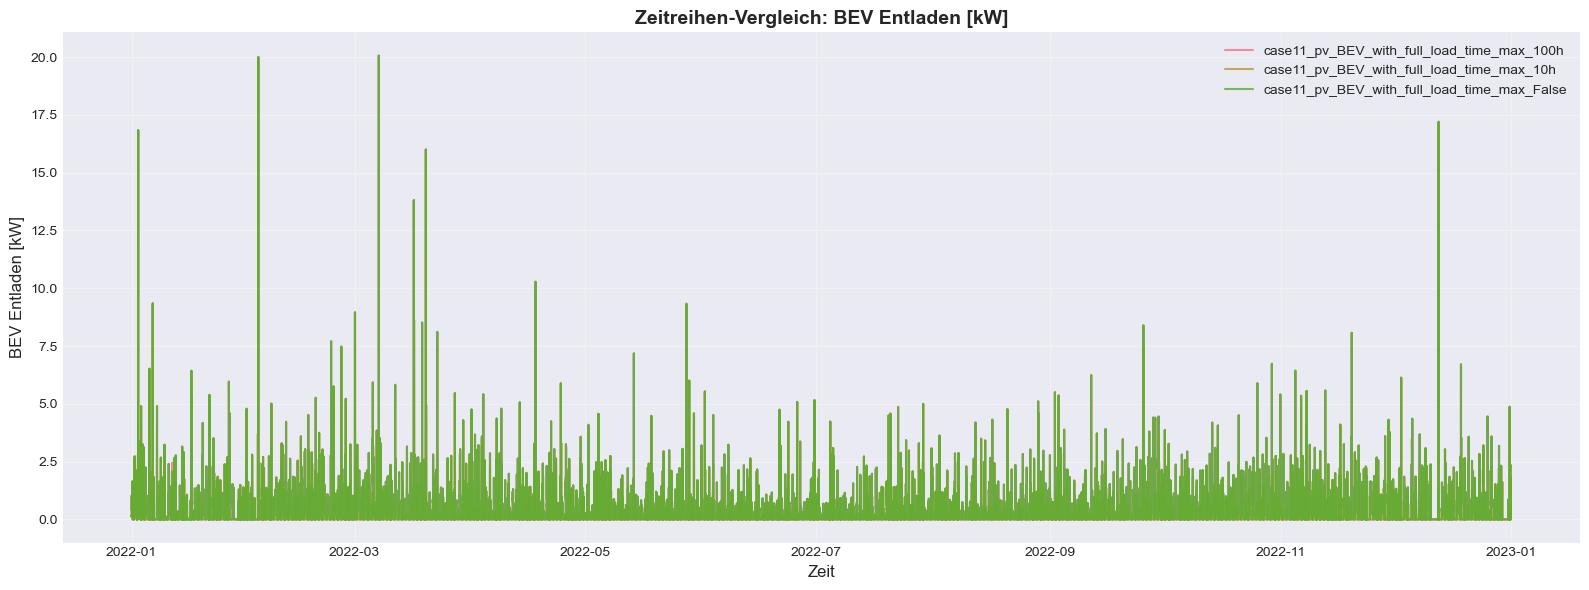

In [13]:
# Zeitreihen-Vergleich für BEV Entladen
column_to_compare = "BEV Entladen [kW]"

if column_to_compare and case_data:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    for case_name, df in case_data.items():
        if column_to_compare in df.columns:
            ax.plot(df.index, df[column_to_compare], label=case_name, linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Zeit', fontsize=12)
    ax.set_ylabel(column_to_compare, fontsize=12)
    ax.set_title(f'Zeitreihen-Vergleich: {column_to_compare}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ Spalte '{column_to_compare}' nicht in allen Cases vorhanden")

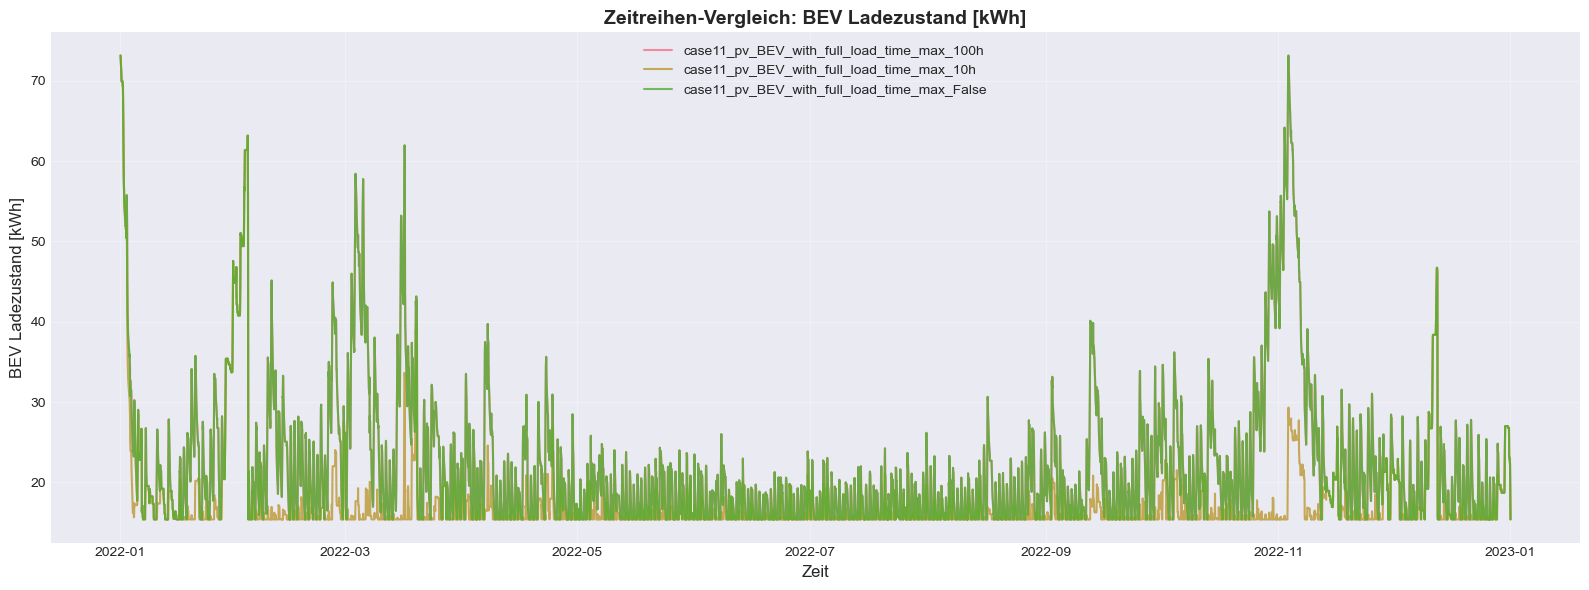

In [14]:
# Zeitreihen-Vergleich für BEV Ladezustand
column_to_compare = "BEV Ladezustand [kWh]"

if column_to_compare and case_data:
    fig, ax = plt.subplots(figsize=(16, 6))
    
    for case_name, df in case_data.items():
        if column_to_compare in df.columns:
            ax.plot(df.index, df[column_to_compare], label=case_name, linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('Zeit', fontsize=12)
    ax.set_ylabel(column_to_compare, fontsize=12)
    ax.set_title(f'Zeitreihen-Vergleich: {column_to_compare}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ Spalte '{column_to_compare}' nicht in allen Cases vorhanden")

## 8. Ergebnisse exportieren

In [15]:
# Exportiere Vergleichstabelle
output_file = Path("cases_comparison_summary.csv")
energy_comparison.to_csv(output_file)
print(f"✓ Vollständige Vergleichstabelle exportiert: {output_file}")

# Exportiere nur Energiesummen
output_file_energy = Path("cases_comparison_energy_sums.csv")
energy_sums_only.to_csv(output_file_energy)
print(f"✓ Energiesummen exportiert: {output_file_energy}")

# Exportiere nur Betriebsstunden
output_file_hours = Path("cases_comparison_betriebsstunden.csv")
betriebsstunden_only.to_csv(output_file_hours)
print(f"✓ Betriebsstunden exportiert: {output_file_hours}")

# Exportiere Volllaststunden
output_file_vlh = Path("cases_comparison_volllaststunden.csv")
volllaststunden_df.to_csv(output_file_vlh)
print(f"✓ Volllaststunden exportiert: {output_file_vlh}")

✓ Vollständige Vergleichstabelle exportiert: cases_comparison_summary.csv
✓ Energiesummen exportiert: cases_comparison_energy_sums.csv
✓ Betriebsstunden exportiert: cases_comparison_betriebsstunden.csv
✓ Volllaststunden exportiert: cases_comparison_volllaststunden.csv


In [16]:
# Erste 10 Zeilen anzeigen
print("\n" + "="*80)
print("ERSTE 10 ZEITSCHRITTE:")
print("="*80)
df.head(10)


ERSTE 10 ZEITSCHRITTE:


,Haushaltslast [kW],PV-Erzeugung [kW],Netzbezug [kW],Netzeinspeisung [kW],BEV Laden [kW],BEV Entladen [kW],BEV Ladezustand [kWh]
2022-01-01 00:00:00,0.132333,0.0,0.0,0.0,0.0,0.147037,73.150000
2022-01-01 00:15:00,0.153600,0.0,0.0,0.0,0.0,0.170667,73.113241
2022-01-01 00:30:00,0.099867,0.0,0.0,0.0,0.0,0.110963,73.070574
2022-01-01 00:45:00,0.144400,0.0,0.0,0.0,0.0,0.160444,73.042833
2022-01-01 01:00:00,0.224800,0.0,0.0,0.0,0.0,0.249778,73.002722
2022-01-01 01:15:00,0.527533,0.0,0.0,0.0,0.0,0.586148,72.940278
2022-01-01 01:30:00,0.940667,0.0,0.0,0.0,0.0,1.045185,72.793741
2022-01-01 01:45:00,0.406600,0.0,0.0,0.0,0.0,0.451778,72.532444
2022-01-01 02:00:00,0.354667,0.0,0.0,0.0,0.0,0.394074,72.419500
2022-01-01 02:15:00,0.670000,0.0,0.0,0.0,0.0,0.744444,72.320981


In [17]:
# Dateninfo und Statistik
print("\n" + "="*80)
print("DATENINFO:")
print("="*80)
df.info()

print("\n" + "="*80)
print("STATISTISCHE ZUSAMMENFASSUNG:")
print("="*80)
df.describe()


DATENINFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35041 entries, 2022-01-01 00:00:00 to 2023-01-01 00:00:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Haushaltslast [kW]     35040 non-null  float64
 1   PV-Erzeugung [kW]      35040 non-null  float64
 2   Netzbezug [kW]         35040 non-null  float64
 3   Netzeinspeisung [kW]   35040 non-null  float64
 4   BEV Laden [kW]         35040 non-null  float64
 5   BEV Entladen [kW]      35040 non-null  float64
 6   BEV Ladezustand [kWh]  35041 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB

STATISTISCHE ZUSAMMENFASSUNG:


,Haushaltslast [kW],PV-Erzeugung [kW],Netzbezug [kW],Netzeinspeisung [kW],BEV Laden [kW],BEV Entladen [kW],BEV Ladezustand [kWh]
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35041.000000
mean,0.571929,1.356565,0.080831,0.749100,0.341922,0.348515,22.086444
std,0.606190,1.854495,0.320504,1.517254,0.908381,0.781026,8.986648
min,0.071667,0.000000,0.000000,0.000000,0.000000,0.000000,15.400000
25%,0.267183,0.000000,0.000000,0.000000,0.000000,0.000000,16.081005
50%,0.403333,0.003045,0.000000,0.000000,0.000000,0.000000,19.080440
75%,0.637017,2.843743,0.000000,0.011089,0.000000,0.472019,24.023990
max,21.295267,5.681149,16.086031,5.541050,5.150955,20.068278,73.150000


In [18]:
# Prüfe auf fehlende Werte
print("\n" + "="*80)
print("FEHLENDE WERTE:")
print("="*80)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ Keine fehlenden Werte")


FEHLENDE WERTE:
Haushaltslast [kW]      1
PV-Erzeugung [kW]       1
Netzbezug [kW]          1
Netzeinspeisung [kW]    1
BEV Laden [kW]          1
BEV Entladen [kW]       1
dtype: int64


## 4. Datenvisualisierung

Erstelle Plots zur Visualisierung der Zeitreihen.

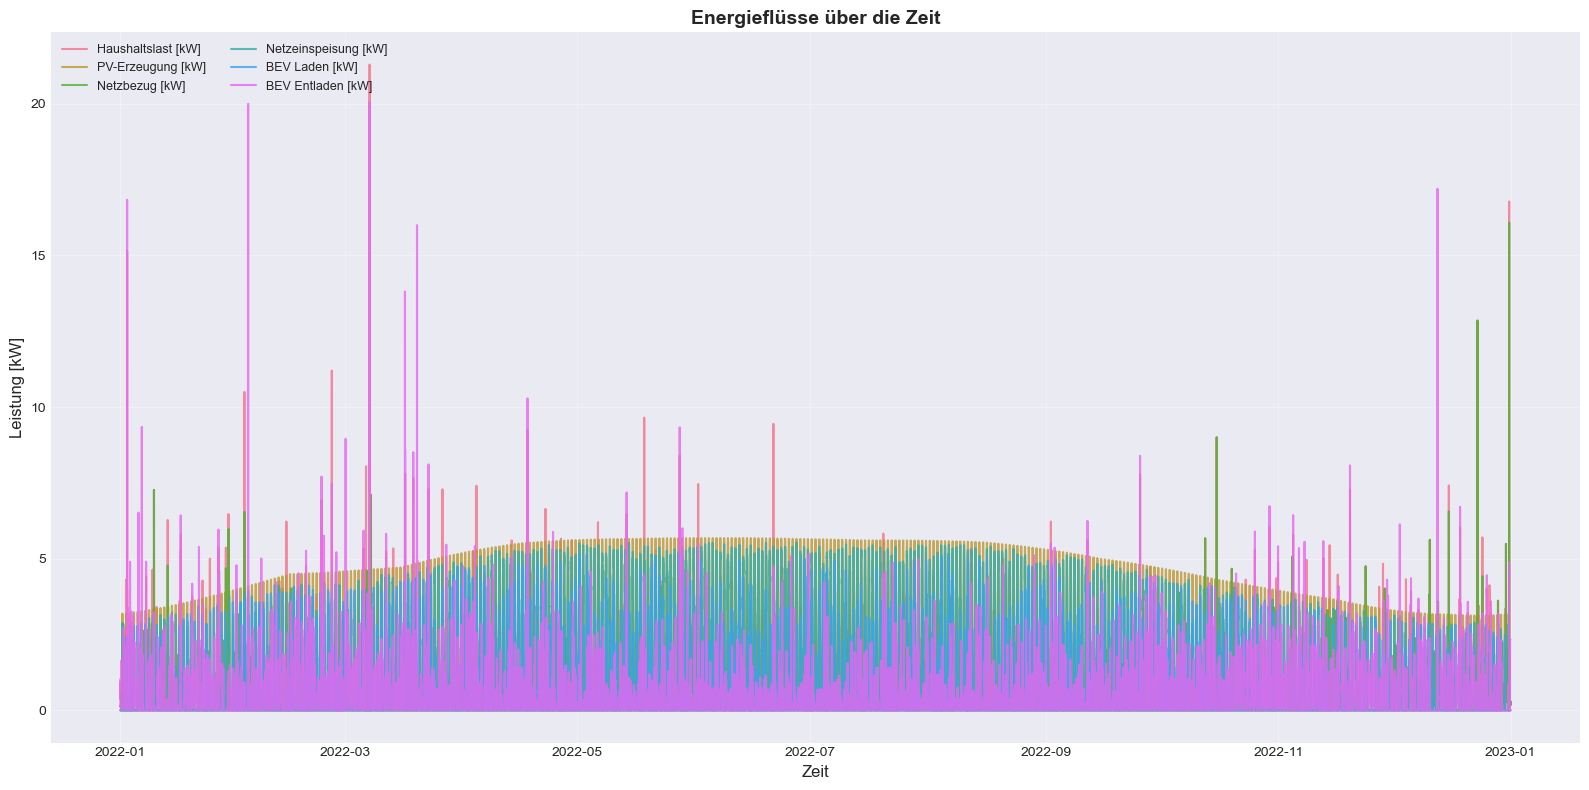

In [19]:
# Plot: Energieflüsse (Leistung in kW)
fig, ax = plt.subplots(figsize=(16, 8))

# Wähle Spalten mit [kW] aus (ohne Ladezustand)
kw_columns = [col for col in df.columns if '[kW]' in col and 'Ladezustand' not in col]

for col in kw_columns:
    ax.plot(df.index, df[col], label=col, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Zeit', fontsize=12)
ax.set_ylabel('Leistung [kW]', fontsize=12)
ax.set_title('Energieflüsse über die Zeit', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

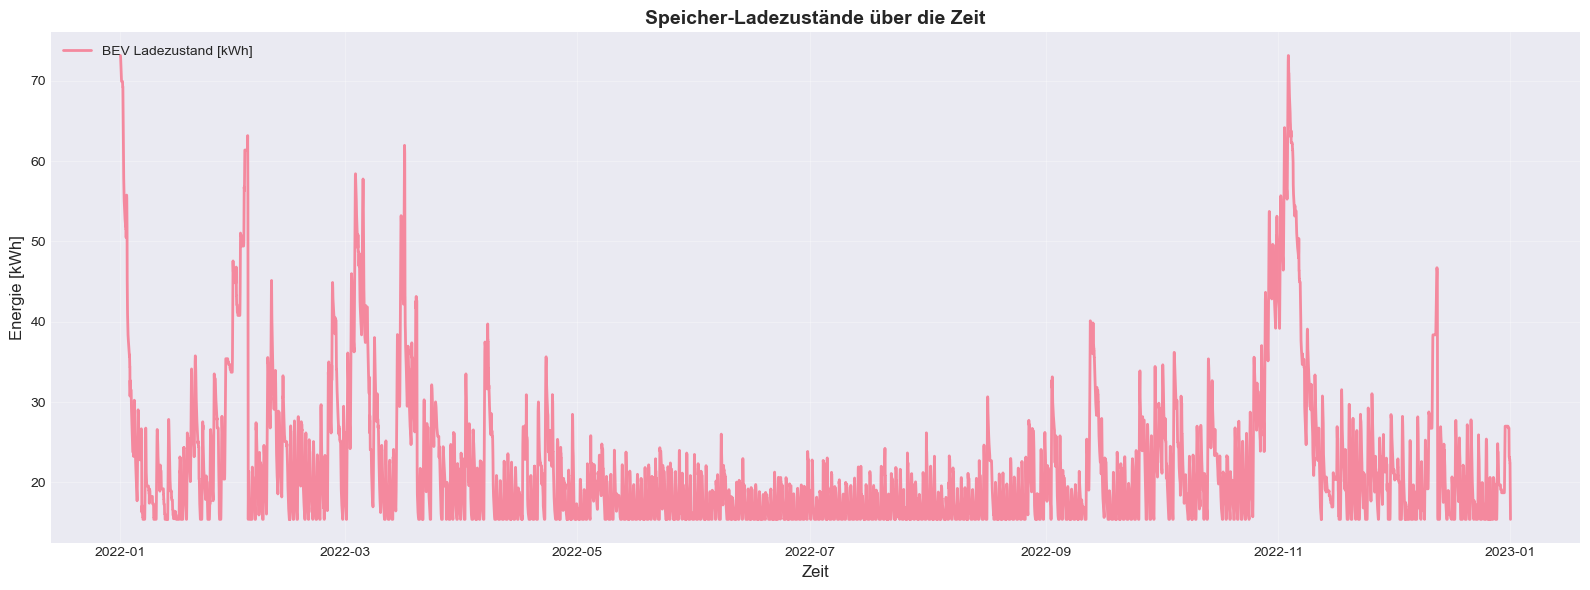

In [20]:
# Plot: Speicher-Ladezustände (Energie in kWh)
fig, ax = plt.subplots(figsize=(16, 6))

# Wähle Spalten mit Ladezustand
soc_columns = [col for col in df.columns if 'Ladezustand' in col]

for col in soc_columns:
    ax.plot(df.index, df[col], label=col, linewidth=2, alpha=0.8)

ax.set_xlabel('Zeit', fontsize=12)
ax.set_ylabel('Energie [kWh]', fontsize=12)
ax.set_title('Speicher-Ladezustände über die Zeit', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Datenbearbeitung

Hier können verschiedene Analysen und Datenbearbeitungen durchgeführt werden.

In [21]:
# Beispiel: Berechne Zeitschrittlänge
if len(df) > 1:
    time_step = (df.index[1] - df.index[0]).total_seconds() / 3600  # in Stunden
    print(f"Zeitschrittlänge: {time_step} Stunden")
    print(f"Das entspricht: {time_step * 60} Minuten")

Zeitschrittlänge: 0.25 Stunden
Das entspricht: 15.0 Minuten


In [22]:
# Beispiel: Energiesummen berechnen
if len(df) > 1:
    time_step_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
    print(time_step_hours)
    print("\n" + "="*80)
    print("ENERGIESUMMEN (für gesamten Zeitraum):")
    print("="*80)
    
    for col in df.columns:
        if '[kW]' in col and 'Ladezustand' not in col:
            energie_kwh = (df[col] * time_step_hours).sum()
            print(f"{col:40s}: {energie_kwh:10.2f} kWh")
    
    print("="*80)

0.25

ENERGIESUMMEN (für gesamten Zeitraum):
Haushaltslast [kW]                      :    5010.10 kWh
PV-Erzeugung [kW]                       :   11883.51 kWh
Netzbezug [kW]                          :     708.08 kWh
Netzeinspeisung [kW]                    :    6562.11 kWh
BEV Laden [kW]                          :    2995.24 kWh
BEV Entladen [kW]                       :    3052.99 kWh


## 6. Weitere Analysen

Füge hier weitere Analysen, Berechnungen oder Datenbearbeitungen hinzu.

**Mögliche Analysen:**
- Tagesmittelwerte berechnen
- Peak-Zeiten identifizieren
- Autarkiegrad berechnen
- Eigenverbrauchsquote berechnen
- Verschiedene Zeiträume vergleichen
- Daten exportieren


In [23]:
# zugriff auf spalte BEV Entladen
BEV_entladen = (df['BEV Entladen [kW]']*(15/60)).sum()  # Beispiel: Umrechnung in kWh bei 15-minütigem Zeitschritt
print("\n" + "="*80)
print("BEV Entladen Zeitreihe:")
print("="*80)
print(BEV_entladen)





BEV Entladen Zeitreihe:
3052.9877964361885


In [24]:
# Berechnung der Betriebsstunden
betriebstunden_BEV_entladen = (df['BEV Entladen [kW]'] > 0).sum() * time_step_hours
print("\n" + "="*80)
print("BETRIEBSSTUNDEN BEV Entladen:")
print(betriebstunden_BEV_entladen)
# Platz für weitere Analysen




BETRIEBSSTUNDEN BEV Entladen:
4339.75


In [25]:
# Übersicht:

# Variante 1, ohne full load time max
# Ergebnisse:


#Varnate 2, mit full load time max, 1000h
#BEV Entladen Zeitreihe:
#3052.99 kWh

#BETRIEBSSTUNDEN BEV Entladen:
#4339.5


#Varnate 3, mit full load time max, 500h
#Ergebnisse:

#Varnate 4, mit full load time max, 200h
#Ergebnisse:



